# 01 Dataset Overview

Stage 1 inventory and Stage 2 label-mapping audit for local DREAMT participant CSV files. This notebook checks file presence, expected columns, label and event annotation columns, missingness, approximate recording duration, and sleep-stage target standardization. It also creates or reloads the fixed participant-level split used downstream, while intentionally avoiding predictive EDA, feature engineering, scaling, and modeling.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
try:
    from IPython.display import display
except ModuleNotFoundError:
    def display(value):
        print(value)

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.data import (
    DEFAULT_EPOCH_INDEX_PATH,
    DEFAULT_INTERIM_DATA_DIR,
    DEFAULT_RAW_DATA_DIR,
    DEFAULT_SPLIT_ASSIGNMENTS_PATH,
    EVENT_ANNOTATION_COLUMNS,
    EXPECTED_DREAMT_COLUMNS,
    EXPECTED_SIGNAL_COLUMNS,
    LABEL_COLUMN,
    check_no_participant_overlap,
    create_participant_split,
    extract_participant_id,
    list_participant_csvs,
    load_split_assignments,
    save_split_assignments,
    summarize_dataset,
    summarize_split_label_distribution,
)

from src.plots import plot_class_balance, summarize_missingness_by_group

from src.preprocessing import (
    TARGET_SLEEP_STAGE_LABELS,
    identify_invalid_labels,
    map_sleep_stage,
    summarize_label_mapping,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

raw_data_dir = repo_root / DEFAULT_RAW_DATA_DIR
summary_path = repo_root / DEFAULT_INTERIM_DATA_DIR / "participant_summary.csv"
epoch_index_path = repo_root / DEFAULT_EPOCH_INDEX_PATH
split_assignments_path = repo_root / DEFAULT_SPLIT_ASSIGNMENTS_PATH
label_mapping_summary_path = repo_root / DEFAULT_INTERIM_DATA_DIR / "label_mapping_summary.csv"
label_mapping_summary_p_as_wake_path = repo_root / DEFAULT_INTERIM_DATA_DIR / "label_mapping_summary_p_as_wake.csv"
expected_n_participants = 100

preflight_participant_files = (
    list_participant_csvs(raw_data_dir) if raw_data_dir.exists() and raw_data_dir.is_dir() else []
)
display(pd.DataFrame([
    {
        "repo_root": str(repo_root),
        "raw_data_dir": str(raw_data_dir),
        "raw_data_dir_exists": raw_data_dir.exists(),
        "participant_files_found": len(preflight_participant_files),
        "participant_summary_exists": summary_path.exists(),
        "label_mapping_summary_exists": label_mapping_summary_path.exists(),
        "split_assignments_exists": split_assignments_path.exists(),
    }
]))

,repo_root,raw_data_dir,raw_data_dir_exists,participant_files_found,participant_summary_exists,label_mapping_summary_exists,split_assignments_exists
0,/home/manns79/dreamt-wearable-sleep-staging,/home/manns79/dreamt-wearable-sleep-staging/data/raw,True,100,False,False,False


## Locate Participant Files

This section checks whether local DREAMT participant CSVs are available under `data/raw/` and lists the files that match the expected participant filename pattern. This answers the first preflight question: can the notebook see the raw data needed to build local summaries? If the raw directory is missing, the notebook keeps going with an empty file list so later sections can either load cached intermediates or show clear fallback messages.

In [2]:
try:
    participant_files = list_participant_csvs(raw_data_dir)
except FileNotFoundError as exc:
    participant_files = []
    print(exc)

participant_file_table = pd.DataFrame(
    {"file_path": [str(path) for path in participant_files]}
)
print(f"Found {len(participant_files)} participant CSV file(s).")
participant_file_table.head()

Found 100 participant CSV file(s).


,file_path
0,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S002_whole_df.csv
1,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S003_whole_df.csv
2,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S004_whole_df.csv
3,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S005_whole_df.csv
4,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S006_whole_df.csv


## Build Or Load Participant Summary

The participant summary is the cached inventory table used by most of the checks below. If `data/interim/participant_summary.csv` already exists, the notebook reloads it; otherwise it scans the raw CSVs and saves the result. When neither raw files nor a saved summary are available, the notebook uses an empty table and downstream cells explain that the summary-dependent outputs cannot be produced yet.

In [3]:
if summary_path.exists():
    summary_df = pd.read_csv(summary_path)
    print(f"Loaded existing summary: {summary_path}")
else:
    try:
        summary_df = summarize_dataset(raw_data_dir, output_path=summary_path)
    except FileNotFoundError as exc:
        print(exc)
        summary_df = pd.DataFrame()

summary_df.head()

Found 100 participant CSV file(s) in /home/manns79/dreamt-wearable-sleep-staging/data/raw.
Saved participant summary to /home/manns79/dreamt-wearable-sleep-staging/data/interim/participant_summary.csv.


,participant_id,file_path,n_rows,n_columns,available_columns,has_expected_schema,has_all_expected_columns,missing_expected_columns,extra_columns,missing_expected_signal_columns,recording_duration_seconds,label_column,label_column_candidates,unique_label_values,label_counts,missing_value_counts_by_signal,missing_value_percentages_by_signal,signal_summary_stats,event_annotation_value_counts,event_annotation_unique_values,error,has_BVP,has_ACC_X,has_ACC_Y,has_ACC_Z,has_TEMP,has_EDA,has_HR,has_IBI,has_Obstructive_Apnea,has_Central_Apnea,has_Hypopnea,has_Multiple_Events
0,S002,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S002_whole_df.csv,2013697,14,"[""TIMESTAMP"", ""BVP"", ""ACC_X"", ""ACC_Y"", ""ACC_Z"", ""TEMP"", ""EDA"", ""HR"", ""IBI"", ""Sleep_Stage"", ""Obstructive_Apnea"", ""Cen...",True,True,[],[],[],31464.0,Sleep_Stage,"[""Sleep_Stage""]","[""N2"", ""P"", ""W"", ""R"", ""N1""]","{""N1"": 122880, ""N2"": 641280, ""P"": 587136, ""R"": 153600, ""W"": 508801}","{""ACC_X"": 0, ""ACC_Y"": 0, ""ACC_Z"": 0, ""BVP"": 0, ""EDA"": 0, ""HR"": 0, ""IBI"": 1488, ""TEMP"": 0}","{""ACC_X"": 0.0, ""ACC_Y"": 0.0, ""ACC_Z"": 0.0, ""BVP"": 0.0, ""EDA"": 0.0, ""HR"": 0.0, ""IBI"": 0.07389393736992209, ""TEMP"": 0.0}","{""ACC_X"": {""max"": 127.0, ""mean"": -5.672155741404988, ""min"": -128.0, ""std"": 26.399859888514456}, ""ACC_Y"": {""max"": 127...","{""Central_Apnea"": {""nan"": 2013697}, ""Hypopnea"": {""1.0"": 87092, ""nan"": 1926605}, ""Multiple_Events"": {""nan"": 2013697},...","{""Central_Apnea"": [""nan""], ""Hypopnea"": [""nan"", ""1.0""], ""Multiple_Events"": [""nan""], ""Obstructive_Apnea"": [""nan"", ""1.0""]}",None,True,True,True,True,True,True,True,True,True,True,True,True
1,S003,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S003_whole_df.csv,2052097,14,"[""TIMESTAMP"", ""BVP"", ""ACC_X"", ""ACC_Y"", ""ACC_Z"", ""TEMP"", ""EDA"", ""HR"", ""IBI"", ""Sleep_Stage"", ""Obstructive_Apnea"", ""Cen...",True,True,[],[],[],32064.0,Sleep_Stage,"[""Sleep_Stage""]","[""N2"", ""P"", ""N3"", ""R"", ""W"", ""N1""]","{""N1"": 61441, ""N2"": 821760, ""N3"": 261120, ""P"": 460416, ""R"": 228480, ""W"": 218880}","{""ACC_X"": 0, ""ACC_Y"": 0, ""ACC_Z"": 0, ""BVP"": 0, ""EDA"": 0, ""HR"": 0, ""IBI"": 20411, ""TEMP"": 0}","{""ACC_X"": 0.0, ""ACC_Y"": 0.0, ""ACC_Z"": 0.0, ""BVP"": 0.0, ""EDA"": 0.0, ""HR"": 0.0, ""IBI"": 0.9946410915273498, ""TEMP"": 0.0}","{""ACC_X"": {""max"": 127.0, ""mean"": -28.90614332558354, ""min"": -128.0, ""std"": 21.08784422300675}, ""ACC_Y"": {""max"": 127....","{""Central_Apnea"": {""1.0"": 8931, ""nan"": 2043166}, ""Hypopnea"": {""1.0"": 150257, ""nan"": 1901840}, ""Multiple_Events"": {""1...","{""Central_Apnea"": [""nan"", ""1.0""], ""Hypopnea"": [""nan"", ""1.0""], ""Multiple_Events"": [""nan"", ""1.0""], ""Obstructive_Apnea""...",None,True,True,True,True,True,True,True,True,True,True,True,True
2,S004,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S004_whole_df.csv,1982145,14,"[""TIMESTAMP"", ""BVP"", ""ACC_X"", ""ACC_Y"", ""ACC_Z"", ""TEMP"", ""EDA"", ""HR"", ""IBI"", ""Sleep_Stage"", ""Obstructive_Apnea"", ""Cen...",True,True,[],[],[],30971.0,Sleep_Stage,"[""Sleep_Stage""]","[""N2"", ""W"", ""P"", ""N1"", ""N3""]","{""N1"": 312960, ""N2"": 814081, ""N3"": 1920, ""P"": 377024, ""W"": 476160}","{""ACC_X"": 0, ""ACC_Y"": 0, ""ACC_Z"": 0, ""BVP"": 0, ""EDA"": 0, ""HR"": 0, ""IBI"": 5902, ""TEMP"": 0}","{""ACC_X"": 0.0, ""ACC_Y"": 0.0, ""ACC_Z"": 0.0, ""BVP"": 0.0, ""EDA"": 0.0, ""HR"": 0.0, ""IBI"": 0.2977582366577622, ""TEMP"": 0.0}","{""ACC_X"": {""max"": 127.0, ""mean"": 6.04392463719859, ""min"": -128.0, ""std"": 39.65400579052804}, ""ACC_Y"": {""max"": 127.0,...","{""Central_Apnea"": {""1.0"": 160898, ""nan"": 1821247}, ""Hypopnea"": {""1.0"": 324647, ""nan"": 1657498}, ""Multiple_Events"": {...","{""Central_Apnea"": [""nan"", ""1.0""], ""Hypopnea"": [""nan"", ""1.0""], ""Multiple_Events"": [""nan"", ""1.0""], ""Obstructive_Apnea""...",None,True,True,True,True,True,True,True,True,True,True,True

In [4]:
def parse_json_cell(value, default=None):
    if default is None:
        default = {}
    if pd.isna(value):
        return default
    try:
        return json.loads(value)
    except (TypeError, json.JSONDecodeError):
        return default


def require_summary(summary):
    if summary.empty:
        print("No participant summary is available yet. Add raw CSVs under data/raw/ and rerun the notebook.")
        return False
    return True

## Participant Count And File Integrity

These cells check whether all 100 expected participant files were found and whether each summarized file matches the expected DREAMT schema. The first output is a compact count check; the second lists per-participant row counts, missing or extra columns, and read errors. This helps catch incomplete downloads, corrupt files, or schema drift before any downstream preprocessing.

In [5]:
participant_count_table = pd.DataFrame(
    [
        {
            "expected_participant_files": expected_n_participants,
            "found_participant_files": len(participant_files),
            "all_100_present": len(participant_files) == expected_n_participants,
        }
    ]
)
participant_count_table

,expected_participant_files,found_participant_files,all_100_present
0,100,100,True


In [6]:
if require_summary(summary_df):
    integrity_columns = [
        "participant_id",
        "n_rows",
        "n_columns",
        "has_expected_schema",
        "has_all_expected_columns",
        "missing_expected_columns",
        "extra_columns",
        "error",
    ]
    display(summary_df[integrity_columns].sort_values(["error", "n_rows"], na_position="last"))

    schema_summary = summary_df["has_expected_schema"].value_counts(dropna=False).rename_axis("has_expected_schema").reset_index(name="n_participants")
    display(schema_summary)

,participant_id,n_rows,n_columns,has_expected_schema,has_all_expected_columns,missing_expected_columns,extra_columns,error
32,S034,1672769,14,True,True,[],[],None
47,S050,1827457,14,True,True,[],[],None
77,S081,1831041,14,True,True,[],[],None
12,S014,1831873,14,True,True,[],[],None
79,S083,1857025,14,True,True,[],[],None
...,...,...,...,...,...,...,...,...
25,S027,2217601,14,True,True,[],[],None
73,S077,2227841,14,True,True,[],[],None
10,S012,2243073,14,True,True,[],[],None
34,S036,2369729,14,True,True,[],[],None


,has_expected_schema,n_participants
0,True,100


## Missing Signals, Labels, And Event Annotations

These cells answer whether each participant file contains the wearable signals, the sleep-stage label column, and the event annotation columns expected by later stages. The first cell reports signal presence by participant and aggregates how many participants are missing each signal. The second cell does the same for `Sleep_Stage` and event annotations, which helps distinguish modeling-critical missing columns from annotations that are documented but not used as targets.

In [7]:
if require_summary(summary_df):
    signal_presence_columns = [f"has_{column}" for column in EXPECTED_SIGNAL_COLUMNS]
    signal_presence = summary_df[["participant_id", *signal_presence_columns]].copy()
    display(signal_presence)

    missing_signal_counts = pd.DataFrame(
        {
            "signal": EXPECTED_SIGNAL_COLUMNS,
            "participants_missing_signal": [
                int((~summary_df[f"has_{column}"].fillna(False).astype(bool)).sum())
                for column in EXPECTED_SIGNAL_COLUMNS
            ],
        }
    )
    display(missing_signal_counts)

,participant_id,has_BVP,has_ACC_X,has_ACC_Y,has_ACC_Z,has_TEMP,has_EDA,has_HR,has_IBI
0,S002,True,True,True,True,True,True,True,True
1,S003,True,True,True,True,True,True,True,True
2,S004,True,True,True,True,True,True,True,True
3,S005,True,True,True,True,True,True,True,True
4,S006,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...
95,S099,True,True,True,True,True,True,True,True
96,S100,True,True,True,True,True,True,True,True
97,S101,True,True,True,True,True,True,True,True
98,S102,True,True,True,True,True,True,True,True


,signal,participants_missing_signal
0,BVP,0
1,ACC_X,0
2,ACC_Y,0
3,ACC_Z,0
4,TEMP,0
5,EDA,0
6,HR,0
7,IBI,0


In [8]:
if require_summary(summary_df):
    label_and_event_columns = [
        "participant_id",
        "label_column",
        *[f"has_{column}" for column in EVENT_ANNOTATION_COLUMNS],
    ]
    display(summary_df[label_and_event_columns])

    missing_label_count = int((summary_df["label_column"] != LABEL_COLUMN).sum())
    event_presence_counts = pd.DataFrame(
        {
            "column": EVENT_ANNOTATION_COLUMNS,
            "participants_missing_column": [
                int((~summary_df[f"has_{column}"].fillna(False).astype(bool)).sum())
                for column in EVENT_ANNOTATION_COLUMNS
            ],
        }
    )
    display(pd.DataFrame([{"missing_sleep_stage_participants": missing_label_count}]))
    display(event_presence_counts)

,participant_id,label_column,has_Obstructive_Apnea,has_Central_Apnea,has_Hypopnea,has_Multiple_Events
0,S002,Sleep_Stage,True,True,True,True
1,S003,Sleep_Stage,True,True,True,True
2,S004,Sleep_Stage,True,True,True,True
3,S005,Sleep_Stage,True,True,True,True
4,S006,Sleep_Stage,True,True,True,True
...,...,...,...,...,...,...
95,S099,Sleep_Stage,True,True,True,True
96,S100,Sleep_Stage,True,True,True,True
97,S101,Sleep_Stage,True,True,True,True
98,S102,Sleep_Stage,True,True,True,True


,missing_sleep_stage_participants
0,0


,column,participants_missing_column
0,Obstructive_Apnea,0
1,Central_Apnea,0
2,Hypopnea,0
3,Multiple_Events,0


## Empty, Corrupted, Or Unusually Short Files

This section flags participant files that failed inventory, have zero rows, or are unusually short relative to the rest of the dataset. The table shows the files that may need attention, and the histogram gives a quick view of row-count variability. If no participant summary is available, the section prints the shared fallback message instead of producing misleading empty diagnostics.

,participant_id,file_path,n_rows,recording_duration_seconds,error
12,S014,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S014_whole_df.csv,1831873,28623.0,None
32,S034,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S034_whole_df.csv,1672769,26137.0,None
47,S050,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S050_whole_df.csv,1827457,28554.0,None
77,S081,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S081_whole_df.csv,1831041,28610.0,None
79,S083,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S083_whole_df.csv,1857025,29016.0,None


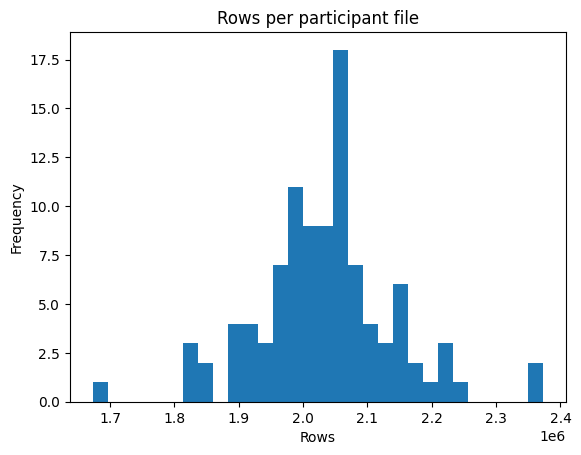

In [9]:
if require_summary(summary_df):
    row_threshold = summary_df["n_rows"].quantile(0.05) if summary_df["n_rows"].notna().any() else None
    short_or_problem_files = summary_df[
        summary_df["error"].notna()
        | summary_df["n_rows"].fillna(0).eq(0)
        | (summary_df["n_rows"] < row_threshold if row_threshold is not None else False)
    ][["participant_id", "file_path", "n_rows", "recording_duration_seconds", "error"]]
    display(short_or_problem_files)

    summary_df["n_rows"].dropna().plot(kind="hist", bins=30, title="Rows per participant file")
    plt.xlabel("Rows")
    plt.show()

## Sleep-Stage And Event Annotation Values

These cells summarize the raw values observed in `Sleep_Stage` and in each event annotation column. The goal is to verify which labels need mapping or exclusion and to document the annotation value vocabulary present in the local files. If the cached summary contains no values for a category, the notebook says so explicitly.

In [10]:
if require_summary(summary_df):
    label_rows = []
    for _, row in summary_df.iterrows():
        for label_value, count in parse_json_cell(row.get("label_counts"), {}).items():
            label_rows.append(
                {
                    "participant_id": row["participant_id"],
                    "sleep_stage_value": label_value,
                    "count": count,
                }
            )
    label_values = pd.DataFrame(label_rows)
    if not label_values.empty:
        display(label_values.groupby("sleep_stage_value", as_index=False)["count"].sum())
    else:
        print("No Sleep_Stage values found in the participant summary.")

,sleep_stage_value,count
0,Missing,120960
1,N1,16965129
2,N2,76978529
3,N3,5191680
4,P,49443712
5,R,16152968
6,W,38678450


In [11]:
if require_summary(summary_df):
    event_rows = []
    for _, row in summary_df.iterrows():
        event_counts = parse_json_cell(row.get("event_annotation_value_counts"), {})
        for column, counts in event_counts.items():
            for value, count in counts.items():
                event_rows.append(
                    {
                        "participant_id": row["participant_id"],
                        "event_column": column,
                        "event_value": value,
                        "count": count,
                    }
                )
    event_values = pd.DataFrame(event_rows)
    if not event_values.empty:
        display(event_values.groupby(["event_column", "event_value"], as_index=False)["count"].sum())
    else:
        print("No event annotation values found in the participant summary.")

,event_column,event_value,count
0,Central_Apnea,1.0,1344206
1,Central_Apnea,nan,202187222
2,Hypopnea,1.0,11815536
3,Hypopnea,nan,191715892
4,Multiple_Events,1.0,370936
5,Multiple_Events,nan,203160492
6,Obstructive_Apnea,1.0,2372537
7,Obstructive_Apnea,nan,201158891


## Missingness By Signal And Participant

This section expands the cached per-participant missingness summaries into a participant-by-signal table and a mean-missingness plot. It also uses the full epoch index, when available, to summarize mean signal missingness by mapped sleep stage and the participant-level distribution of mean signal missingness. These checks are descriptive only and are not used to inform predictive modeling.


signal,ACC_X,ACC_Y,ACC_Z,BVP,EDA,HR,IBI,TEMP
participant_id,,,,,,,,
S002,0.0,0.0,0.0,0.0,0.0,0.0,0.073894,0.0
S003,0.0,0.0,0.0,0.0,0.0,0.0,0.994641,0.0
S004,0.0,0.0,0.0,0.0,0.0,0.0,0.297758,0.0
S005,0.0,0.0,0.0,0.0,0.0,0.0,0.007430,0.0
S006,0.0,0.0,0.0,0.0,0.0,0.0,0.055418,0.0
...,...,...,...,...,...,...,...,...
S099,0.0,0.0,0.0,0.0,0.0,0.0,0.170974,0.0
S100,0.0,0.0,0.0,0.0,0.0,0.0,0.351676,0.0
S101,0.0,0.0,0.0,0.0,0.0,0.0,0.364982,0.0


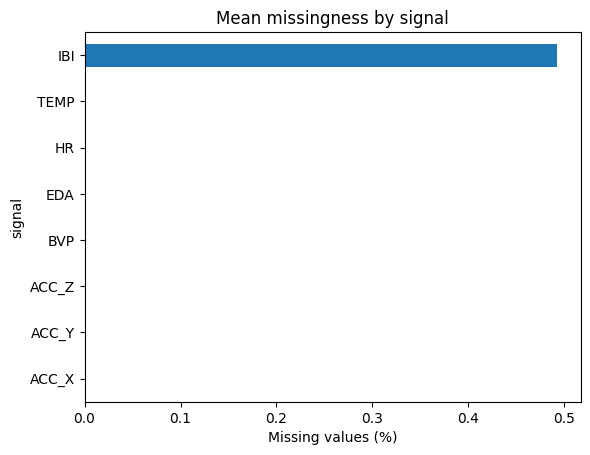

Epoch index not found at /home/manns79/dreamt-wearable-sleep-staging/data/interim/epoch_index.csv; skipping epoch-level missingness tables.


In [12]:
if require_summary(summary_df):
    missingness_rows = []
    for _, row in summary_df.iterrows():
        percentages = parse_json_cell(row.get("missing_value_percentages_by_signal"), {})
        for signal, missing_pct in percentages.items():
            missingness_rows.append(
                {
                    "participant_id": row["participant_id"],
                    "signal": signal,
                    "missing_pct": missing_pct,
                }
            )
    missingness = pd.DataFrame(missingness_rows)
    if not missingness.empty:
        display(missingness.pivot(index="participant_id", columns="signal", values="missing_pct"))
        missingness.groupby("signal")["missing_pct"].mean().sort_values().plot(kind="barh", title="Mean missingness by signal")
        plt.xlabel("Missing values (%)")
        plt.show()
    else:
        print("No signal missingness values found in the participant summary.")

if epoch_index_path.exists():
    epoch_index = pd.read_csv(epoch_index_path)
    required_columns = {"participant_id", "mapped_label", "is_valid_epoch"}
    missing_columns = sorted(required_columns - set(epoch_index.columns))
    if missing_columns:
        print(f"Epoch index is missing column(s): {missing_columns}; skipping epoch-level missingness tables.")
    else:
        valid_epochs = epoch_index[epoch_index["is_valid_epoch"].astype(bool)].copy()
        valid_epochs = valid_epochs[valid_epochs["mapped_label"].isin(TARGET_SLEEP_STAGE_LABELS)].copy()
        missingness_by_participant = summarize_missingness_by_group(
            valid_epochs,
            "participant_id",
        )
        missingness_by_stage = summarize_missingness_by_group(
            valid_epochs,
            "mapped_label",
        )
        if missingness_by_stage.empty or missingness_by_participant.empty:
            print("No epoch-level missingness values found in the epoch index.")
        else:
            stage_missingness_table = missingness_by_stage.pivot_table(
                index="signal",
                columns="mapped_label",
                values="mean_missingness",
            ).reindex(columns=list(TARGET_SLEEP_STAGE_LABELS))
            display(stage_missingness_table)

            participant_missingness_table = missingness_by_participant.pivot_table(
                index="participant_id",
                columns="signal",
                values="mean_missingness",
            )
            display(participant_missingness_table.describe())
else:
    print(f"Epoch index not found at {epoch_index_path}; skipping epoch-level missingness tables.")


## Approximate Recording Duration

This section converts each participant's summarized recording duration into hours and plots the distribution. It helps identify participants with unexpectedly short or long recordings that could affect epoch counts and split balance. The calculation uses summary metadata only and does not inspect raw signals again.

,participant_id,recording_duration_seconds,recording_duration_hours
32,S034,26137.0,7.260278
47,S050,28554.0,7.931667
77,S081,28610.0,7.947222
12,S014,28623.0,7.950833
79,S083,29016.0,8.060000
...,...,...,...
25,S027,34650.0,9.625000
73,S077,34810.0,9.669444
10,S012,35048.0,9.735556
34,S036,37027.0,10.285278


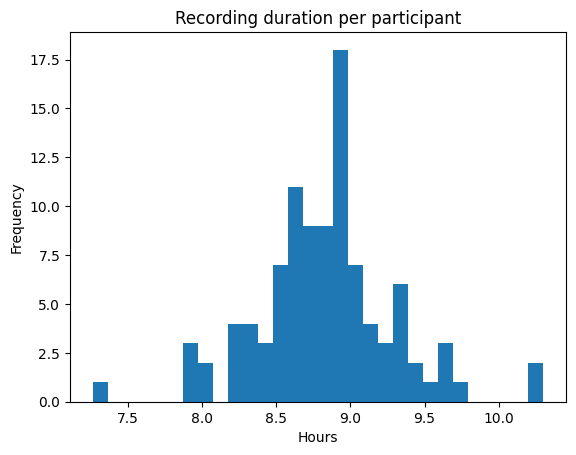

In [13]:
if require_summary(summary_df):
    duration = summary_df[["participant_id", "recording_duration_seconds"]].copy()
    duration["recording_duration_hours"] = duration["recording_duration_seconds"] / 3600
    display(duration.sort_values("recording_duration_seconds"))

    duration["recording_duration_hours"].dropna().plot(kind="hist", bins=30, title="Recording duration per participant")
    plt.xlabel("Hours")
    plt.show()

## Three-Class Label Mapping

The primary project target is `Wake`, `Non-REM`, and `REM`. PSG stages `N1`, `N2`, and `N3` are grouped as `Non-REM`. DREAMT `data_64Hz` labels include `P` for preparation before PSG recording starts; the primary mapping excludes `P`, while a secondary sensitivity mapping can treat `P` as `Wake` to match the `data_100Hz` convention. The next cell loads saved mapping summaries when available, creates both summaries from raw files when needed, or leaves the section empty with a clear message when neither source exists.


In [14]:
if label_mapping_summary_path.exists() and label_mapping_summary_p_as_wake_path.exists():
    label_mapping_summary = pd.read_csv(label_mapping_summary_path)
    label_mapping_summary_p_as_wake = pd.read_csv(label_mapping_summary_p_as_wake_path)
    print(f"Loaded existing primary label mapping summary: {label_mapping_summary_path}")
    print(f"Loaded existing P-as-Wake sensitivity summary: {label_mapping_summary_p_as_wake_path}")
elif participant_files:
    label_mapping_summary = summarize_label_mapping(
        participant_files,
        p_as_wake=False,
        output_path=label_mapping_summary_path,
    )
    label_mapping_summary_p_as_wake = summarize_label_mapping(
        participant_files,
        p_as_wake=True,
        output_path=label_mapping_summary_p_as_wake_path,
    )
    print(f"Saved primary label mapping summary to {label_mapping_summary_path}")
    print(f"Saved P-as-Wake sensitivity summary to {label_mapping_summary_p_as_wake_path}")
else:
    label_mapping_summary = pd.DataFrame()
    label_mapping_summary_p_as_wake = pd.DataFrame()
    print(
        "No participant files or saved label mapping summaries are available. "
        "Add raw CSVs under data/raw/ and rerun this section."
    )

label_mapping_summary.head()


Saved primary label mapping summary to /home/manns79/dreamt-wearable-sleep-staging/data/interim/label_mapping_summary.csv
Saved P-as-Wake sensitivity summary to /home/manns79/dreamt-wearable-sleep-staging/data/interim/label_mapping_summary_p_as_wake.csv


,scope,participant_id,file_path,label_column,raw_label,standardized_label,mapped_label,invalid_reason,count,p_as_wake,mapping_note
0,participant,S002,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S002_whole_df.csv,Sleep_Stage,N1,N1,Non-REM,NaN,122880,False,Primary mapping excludes DREAMT data_64Hz preparation-stage P labels.
1,participant,S002,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S002_whole_df.csv,Sleep_Stage,N2,N2,Non-REM,NaN,641280,False,Primary mapping excludes DREAMT data_64Hz preparation-stage P labels.
2,participant,S002,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S002_whole_df.csv,Sleep_Stage,P,P,NaN,Preparation,587136,False,Primary mapping excludes DREAMT data_64Hz preparation-stage P labels.
3,participant,S002,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S002_whole_df.csv,Sleep_Stage,R,REM,REM,NaN,153600,False,Primary mapping excludes DREAMT data_64Hz preparation-stage P labels.
4,participant,S002,/home/manns79/dreamt-wearable-sleep-staging/data/raw/S002_whole_df.csv,Sleep_Stage,W,W,Wake,NaN,508801,False,Primary mapping excludes DREAMT data_64Hz preparation-stage P labels.


### Raw And Mapped Label Counts

This subsection shows how every raw sleep-stage value contributes to the three target classes or to an exclusion reason. The mapped-count table is the dataset-level target distribution before the participant split is applied.

,raw_label,standardized_label,mapped_label,invalid_reason,count
543,<MISSING>,NaN,NaN,Missing,120960
547,P,P,NaN,Preparation,49443712
544,N1,N1,Non-REM,NaN,16965129
545,N2,N2,Non-REM,NaN,76978529
546,N3,N3,Non-REM,NaN,5191680
548,R,REM,REM,NaN,16152968
549,W,W,Wake,NaN,38678450


,mapped_label,count
0,Non-REM,99135338
1,REM,16152968
2,Wake,38678450


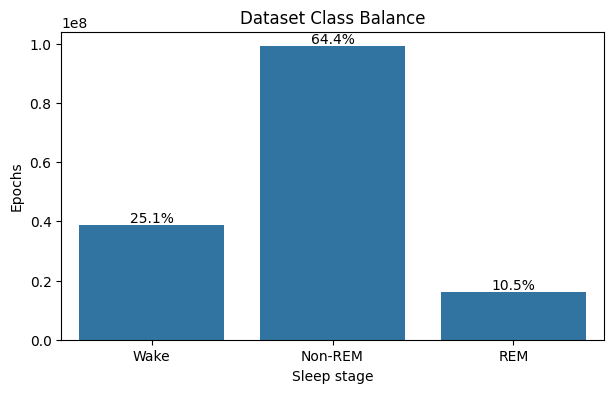

In [15]:
if not label_mapping_summary.empty:
    primary_dataset_rows = label_mapping_summary[label_mapping_summary["scope"] == "dataset"]
    raw_counts = primary_dataset_rows[["raw_label", "standardized_label", "mapped_label", "invalid_reason", "count"]]
    display(raw_counts.sort_values(["invalid_reason", "mapped_label", "raw_label"], na_position="last"))

    mapped_counts = (
        primary_dataset_rows.dropna(subset=["mapped_label"])
        .groupby("mapped_label", as_index=False)["count"]
        .sum()
        .sort_values("mapped_label")
    )
    display(mapped_counts)

    dataset_class_balance = (
        mapped_counts.set_index("mapped_label")
        .reindex(TARGET_SLEEP_STAGE_LABELS, fill_value=0)
        .rename_axis("mapped_label")
        .reset_index()
        .rename(columns={"count": "n_epochs"})
    )
    total_epochs = dataset_class_balance["n_epochs"].sum()
    dataset_class_balance["percentage"] = (
        dataset_class_balance["n_epochs"] / total_epochs * 100 if total_epochs else 0
    )
    fig, ax = plot_class_balance(dataset_class_balance)
    ax.set_ylabel("Epochs")
    ax.set_title("Dataset Class Balance")
    plt.show()
else:
    print("Raw and mapped label counts are unavailable because label_mapping_summary is empty.")


### Exclusions Under Primary Mapping

This subsection separates labels excluded because they are preparation-stage `P` from labels excluded because they are missing, unknown, or otherwise invalid. That distinction matters because `P` has a planned sensitivity mapping, while other invalid labels generally remain unusable.

In [16]:
if not label_mapping_summary.empty:
    primary_dataset_rows = label_mapping_summary[label_mapping_summary["scope"] == "dataset"]
    exclusions = (
        primary_dataset_rows.dropna(subset=["invalid_reason"])
        .groupby("invalid_reason", as_index=False)["count"]
        .sum()
        .sort_values("invalid_reason")
    )
    display(exclusions)

    excluded_due_to_p = int(exclusions.loc[exclusions["invalid_reason"] == "Preparation", "count"].sum())
    excluded_missing_or_other = int(exclusions.loc[exclusions["invalid_reason"] != "Preparation", "count"].sum())
    display(pd.DataFrame([
        {
            "excluded_due_to_P": excluded_due_to_p,
            "excluded_due_to_missing_or_other_invalid": excluded_missing_or_other,
        }
    ]))
else:
    print("Exclusion counts are unavailable because label_mapping_summary is empty.")


,invalid_reason,count
0,Missing,120960
1,Preparation,49443712


,excluded_due_to_P,excluded_due_to_missing_or_other_invalid
0,49443712,120960


### Preparation-Stage Counts By Participant

This table identifies participants with the most `P` rows under the primary mapping. It helps assess whether preparation-stage data are concentrated in a few files or spread broadly across the dataset.

In [17]:
if not label_mapping_summary.empty:
    participant_p_counts = (
        label_mapping_summary[
            (label_mapping_summary["scope"] == "participant")
            & (label_mapping_summary["standardized_label"] == "P")
        ][["participant_id", "count"]]
        .rename(columns={"count": "p_count"})
        .sort_values(["p_count", "participant_id"], ascending=[False, True])
    )
    display(participant_p_counts)
else:
    print("Preparation-stage counts are unavailable because label_mapping_summary is empty.")


,participant_id,p_count
185,S035,689344
452,S088,675328
365,S071,669440
146,S028,667584
240,S046,663872
...,...,...
70,S014,303552
179,S034,298048
229,S044,288640
476,S092,279040


### Participants With Little Or No Target-Class Coverage

This subsection looks for participants with no rows in at least one target class or very few mapped target rows overall. Those participants may affect class balance, epoch availability, or the stability of participant-level split summaries.

In [18]:
if not label_mapping_summary.empty:
    participant_target_counts = (
        label_mapping_summary[
            (label_mapping_summary["scope"] == "participant")
            & label_mapping_summary["mapped_label"].notna()
        ]
        .pivot_table(
            index="participant_id",
            columns="mapped_label",
            values="count",
            aggfunc="sum",
            fill_value=0,
        )
        .rename_axis(columns=None)
        .reset_index()
    )
    for target_label in ["Wake", "Non-REM", "REM"]:
        if target_label not in participant_target_counts.columns:
            participant_target_counts[target_label] = 0
    class_totals = participant_target_counts[["Wake", "Non-REM", "REM"]].sum(axis=1)
    low_coverage_threshold = 10
    low_or_missing_class_counts = participant_target_counts[
        (participant_target_counts[["Wake", "Non-REM", "REM"]] == 0).any(axis=1)
        | (class_totals < low_coverage_threshold)
    ].sort_values("participant_id")
    display(low_or_missing_class_counts)
else:
    print("Participant target-class coverage is unavailable because label_mapping_summary is empty.")


,participant_id,Non-REM,REM,Wake
2,S004,1128961,0,476160
4,S006,1134721,0,483840
25,S027,704640,0,852481
27,S029,1059840,0,485761
51,S054,1294081,0,240000
52,S055,526081,0,954240
55,S058,994560,0,529921
68,S072,566400,0,840961
77,S081,1142401,0,261120
78,S082,213120,0,1188481


### Primary Versus P-As-Wake Sensitivity Counts

This comparison shows how target counts change if preparation-stage `P` rows are treated as `Wake` instead of excluded. It is a sensitivity check, not the primary modeling definition.

In [19]:
if not label_mapping_summary.empty and not label_mapping_summary_p_as_wake.empty:
    comparison_rows = []
    for mode_name, summary in [
        ("primary_P_excluded", label_mapping_summary),
        ("sensitivity_P_as_Wake", label_mapping_summary_p_as_wake),
    ]:
        dataset_rows = summary[summary["scope"] == "dataset"]
        class_counts = (
            dataset_rows.dropna(subset=["mapped_label"])
            .groupby("mapped_label")["count"]
            .sum()
            .to_dict()
        )
        exclusion_counts = (
            dataset_rows.dropna(subset=["invalid_reason"])
            .groupby("invalid_reason")["count"]
            .sum()
            .to_dict()
        )
        comparison_rows.append({
            "mapping": mode_name,
            "Wake": class_counts.get("Wake", 0),
            "Non-REM": class_counts.get("Non-REM", 0),
            "REM": class_counts.get("REM", 0),
            "excluded_P": exclusion_counts.get("Preparation", 0),
            "excluded_missing_or_other_invalid": sum(
                count for reason, count in exclusion_counts.items() if reason != "Preparation"
            ),
        })
    display(pd.DataFrame(comparison_rows))
else:
    print(
        "Primary versus P-as-Wake sensitivity counts are unavailable because "
        "one or both label mapping summaries are empty."
    )


,mapping,Wake,Non-REM,REM,excluded_P,excluded_missing_or_other_invalid
0,primary_P_excluded,38678450,99135338,16152968,49443712,120960
1,sensitivity_P_as_Wake,88122162,99135338,16152968,0,120960


## Participant-Level Split

Create or load the fixed participant-level train/validation/test split. Downstream EDA, preprocessing, feature extraction, and modeling should reuse `data/interim/split_assignments.csv` rather than resplitting participants. If the split file is missing, the notebook creates the default 70/15/15 split only when all 100 expected participant files are present; otherwise it avoids creating a partial split.


In [20]:
split_df = pd.DataFrame(columns=["participant_id", "split"])

if split_assignments_path.exists():
    split_df = load_split_assignments(split_assignments_path)
    print(f"Loaded existing split assignments: {split_assignments_path}")
elif len(participant_files) == expected_n_participants:
    participant_ids = [extract_participant_id(path) for path in participant_files]
    split_df = create_participant_split(participant_ids, random_state=42)
    save_split_assignments(split_df, split_assignments_path)
    print(f"Saved split assignments: {split_assignments_path}")
elif participant_files:
    print(
        "Default 70/15/15 split was not created because "
        f"{len(participant_files)} participant file(s) were found, "
        f"not {expected_n_participants}."
    )
else:
    print("No participant files or saved split assignments are available yet.")

if not split_df.empty:
    check_no_participant_overlap(split_df)
    display(split_df["split"].value_counts().reindex(["train", "validation", "test"]))
    display(split_df.sort_values(["split", "participant_id"]).reset_index(drop=True))


Saved split assignments: /home/manns79/dreamt-wearable-sleep-staging/data/interim/split_assignments.csv


split
train         70
validation    15
test          15
Name: count, dtype: int64

,participant_id,split
0,S010,test
1,S014,test
2,S015,test
3,S016,test
4,S021,test
...,...,...
95,S086,validation
96,S089,validation
97,S092,validation
98,S094,validation


### Split Label Distribution

This subsection joins the saved participant split to the label-mapping summary to show target-label counts by train, validation, and test. It answers whether the fixed split has reasonable label coverage before downstream notebooks use it. If either the split or label summary is unavailable, the notebook reports which prerequisite is missing.

,split,num_participants,total_epochs,Wake_count,Non_REM_count,REM_count,Wake_percentage,Non_REM_percentage,REM_percentage
0,train,70,107318406,29214754,67209565,10894087,27.222501,62.626317,10.151182
1,validation,15,23091855,4051208,16312326,2728321,17.543883,70.641038,11.815079
2,test,15,23556495,5412488,15613447,2530560,22.976627,66.280858,10.742515


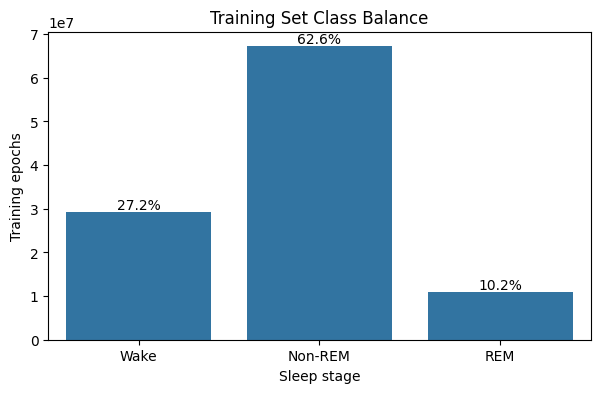

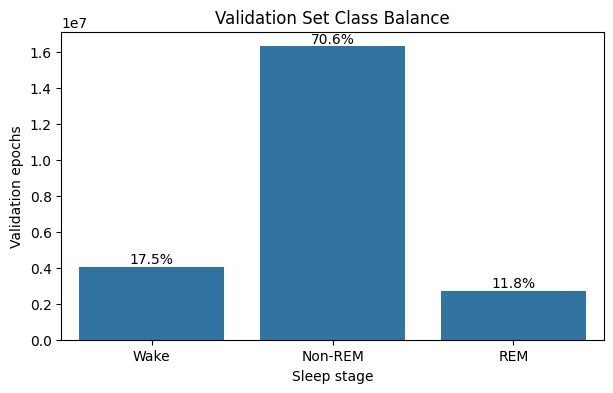

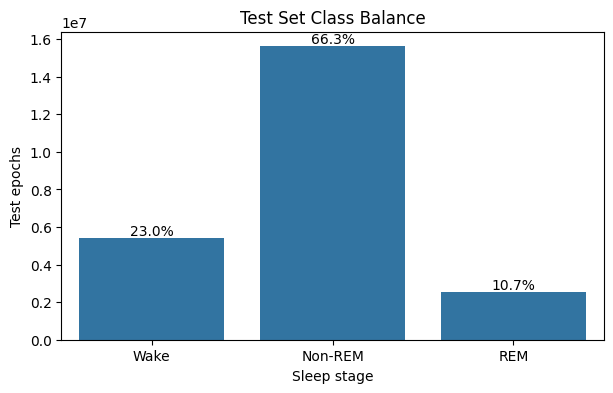

In [21]:
if not split_df.empty and not label_mapping_summary.empty:
    split_label_summary = summarize_split_label_distribution(label_mapping_summary, split_df)
    display(split_label_summary)

    split_plot_labels = {
        "train": "Training Set Class Balance",
        "validation": "Validation Set Class Balance",
        "test": "Test Set Class Balance",
    }
    split_axis_labels = {
        "train": "Training epochs",
        "validation": "Validation epochs",
        "test": "Test epochs",
    }
    for split_name, plot_title in split_plot_labels.items():
        split_row = split_label_summary[split_label_summary["split"] == split_name]
        if split_row.empty:
            continue
        split_class_balance = pd.DataFrame(
            {
                "mapped_label": list(TARGET_SLEEP_STAGE_LABELS),
                "n_epochs": [
                    int(split_row[f"{label.replace('-', '_')}_count"].iloc[0])
                    for label in TARGET_SLEEP_STAGE_LABELS
                ],
            }
        )
        total_epochs = split_class_balance["n_epochs"].sum()
        split_class_balance["percentage"] = (
            split_class_balance["n_epochs"] / total_epochs * 100 if total_epochs else 0
        )
        fig, ax = plot_class_balance(split_class_balance)
        ax.set_ylabel(split_axis_labels[split_name])
        ax.set_title(plot_title)
        plt.show()
elif split_df.empty:
    print("Split assignments are not available yet.")
else:
    print("Label mapping summary is not available yet.")


## Summary Notes

Use the tables above to document whether all 100 expected participant files are present, whether the known DREAMT schema is consistent, which wearable signals or annotation columns are missing, how raw PSG labels map to the three-class target, whether the participant-level split is saved and disjoint, and whether any participant files need attention before downstream train-only EDA or modeling begins.
